In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
coffee_sales = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\UNIFIED MENTOR PRIVATE LIMITED\Project 1\Excel\Coffee_sales.csv")
df = pd.DataFrame(coffee_sales)
# Quick look 
print(df.head()) 
print(df.info()) 
print(df.describe())

        date  datetime cash_type                 card  money    coffee_name
0  01-Mar-24  10:15:51      card  ANON-0000-0000-0001   38.7          Latte
1  01-Mar-24  12:19:23      card  ANON-0000-0000-0002   38.7  Hot Chocolate
2  01-Mar-24  12:20:18      card  ANON-0000-0000-0002   38.7  Hot Chocolate
3  01-Mar-24  13:46:33      card  ANON-0000-0000-0003   28.9      Americano
4  01-Mar-24  13:48:15      card  ANON-0000-0000-0004   38.7          Latte
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1133 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB
None
             money
count  1133.000000
mean  

# Data Cleaning & Transformation

In [40]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()


# Monthly Coffee Sales 

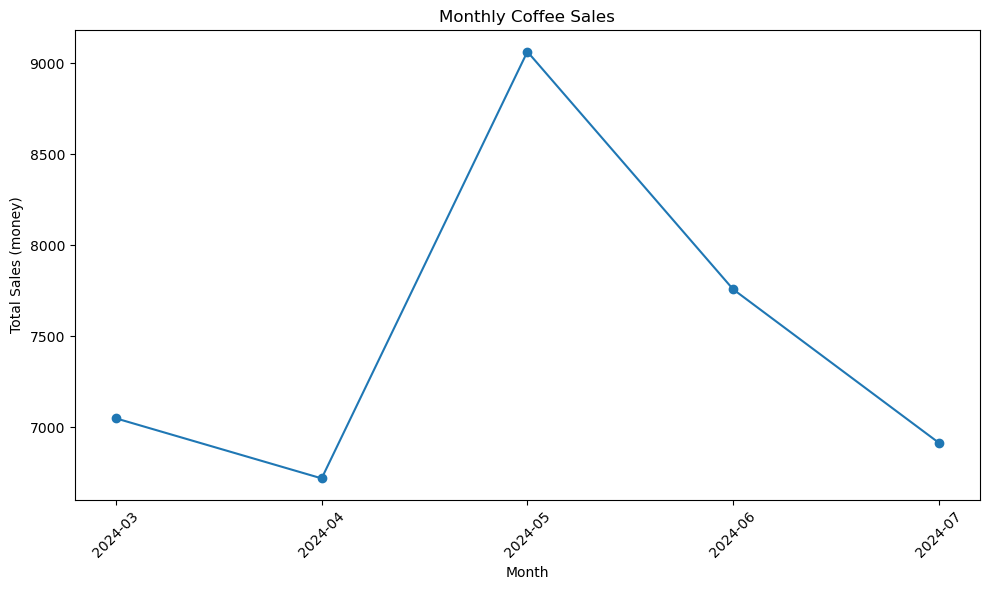

In [34]:
df['date'] = pd.to_datetime(df['date'], format="%d-%b-%y")

# Extract month
df['month'] = df['date'].dt.to_period('M')

# Aggregate sales by month
monthly_sales = df.groupby('month')['money'].sum().reset_index()

# Plot monthly sales
plt.figure(figsize=(10,6))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['money'], marker='o')
plt.title("Monthly Coffee Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales (money)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Coffee Sales by Weekday & hour

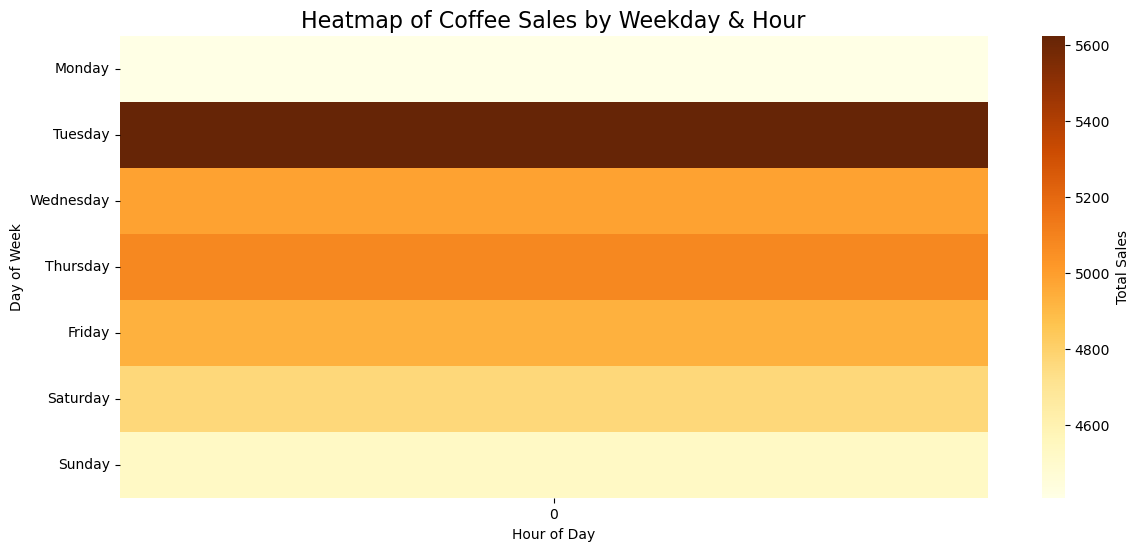

In [46]:
# If there's a single datetime column (date+time together)
df['datetime'] = pd.to_datetime(df['date'], errors='coerce')
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Pivot: Sales by weekday and hour
pivot = df.pivot_table(values='money', index='weekday', columns='hour', aggfunc='sum')

# Reorder weekdays
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot.reindex(weekdays_order)

# Plot heatmap
plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="YlOrBr", annot=False, cbar_kws={'label': 'Total Sales'})
plt.title("Heatmap of Coffee Sales by Weekday & Hour", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


# Monthly Coffee sales by Cash Type

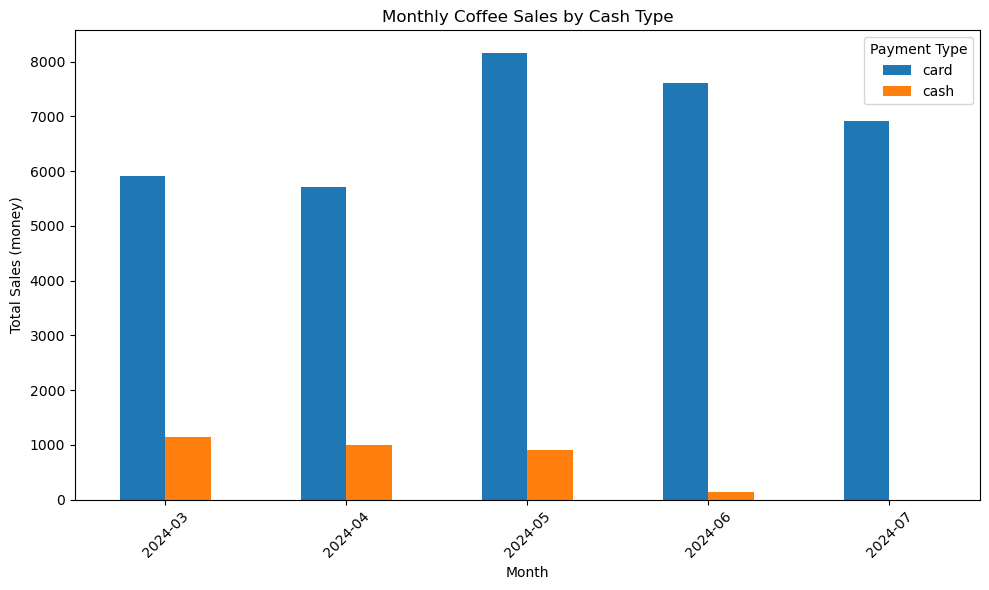

In [35]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'], format="%d-%b-%y")

# Extract month
df['month'] = df['date'].dt.to_period('M')

# Aggregate sales by month and cash_type
monthly_cash_sales = df.groupby(['month', 'cash_type'])['money'].sum().reset_index()

# Pivot for visualization
pivot_sales = monthly_cash_sales.pivot(index='month', columns='cash_type', values='money').fillna(0)

# Plot
pivot_sales.plot(kind='bar', figsize=(10,6))
plt.title("Monthly Coffee Sales by Cash Type")
plt.xlabel("Month")
plt.ylabel("Total Sales (money)")
plt.xticks(rotation=45)
plt.legend(title="Payment Type")
plt.tight_layout()
plt.show()

# Sales trend over time 

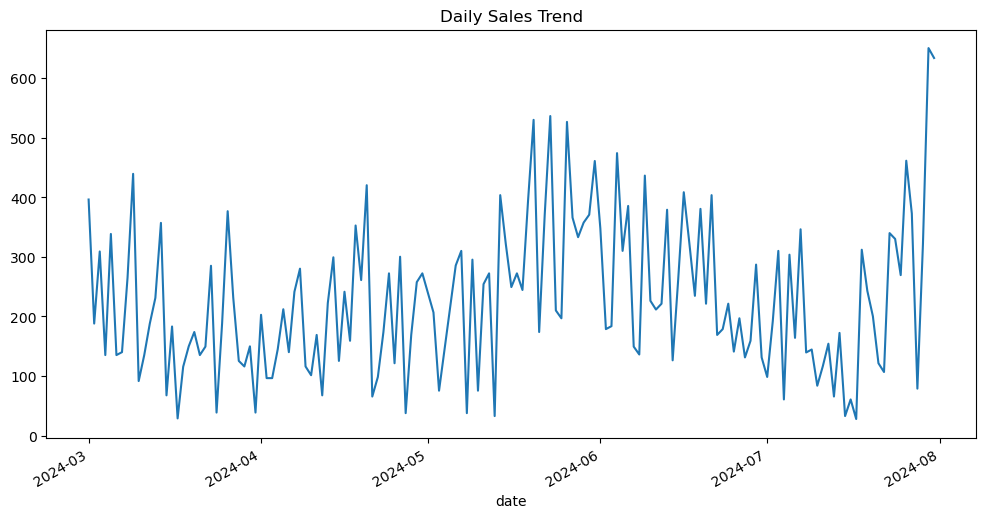

In [43]:

# Sales trend over time
df.groupby('date')['money'].sum().plot(figsize=(12,6), title="Daily Sales Trend")
plt.show()


# Top-selling coffee products

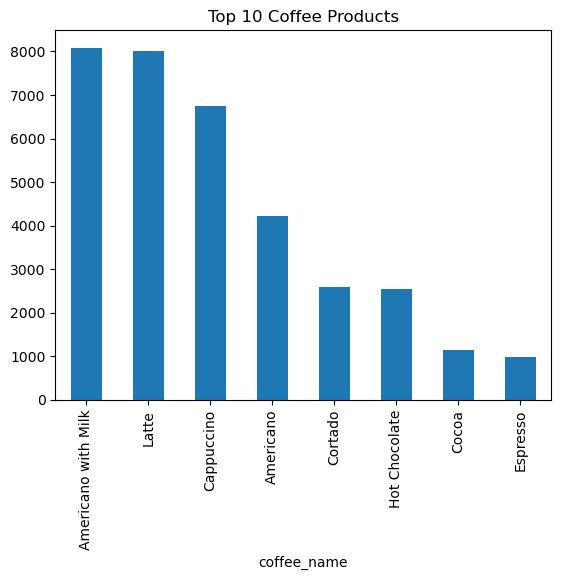

In [42]:
# Top products
df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title="Top 10 Coffee Products")
plt.show()
